In [2]:
import sys

!pip install -q --no-warn-conflicts transformers torch matplotlib requests

try:
    import transformers
    import torch
    import requests
    print("✅ Environment ready. Dependencies loaded successfully.")
except ImportError as e:
    print(f"❌ Critical Error: {e}")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.26a0+c5e1555-py3.12-linux-x86_64.egg is deprecated. pip 25.1 wi

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment ready. Dependencies loaded successfully.


In [3]:
import json
import requests
import re

def load_gsm8k(url):
    response = requests.get(url)
    data = [json.loads(line) for line in response.text.strip().split('\n')]
    return data

train_url = "https://raw.githubusercontent.com/openai/grade-school-math/master/grade_school_math/data/train.jsonl"
test_url = "https://raw.githubusercontent.com/openai/grade-school-math/master/grade_school_math/data/test.jsonl"

train_data = load_gsm8k(train_url)[:300]
test_data = load_gsm8k(test_url)[:50]

print(f"Loaded {len(train_data)} train samples and {len(test_data)} test samples.")

Loaded 300 train samples and 50 test samples.


In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/phi-2"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map="cpu", 
    torch_dtype=torch.float32,
    trust_remote_code=True
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 453/453 [00:00<00:00, 1353.79it/s]


In [5]:
from collections import Counter

def extract_answer(text):
    match = re.findall(r"####\s?(-?\d+(?:\.\d+)?)", text)
    if match:
        return match[-1]
    numbers = re.findall(r"(-?\d+(?:\.\d+)?)", text)
    return numbers[-1] if numbers else None

def generate_answers(question, n_samples=5):
    prompt = f"Question: {question}\nAnswer: Let's think step by step."
    inputs = tokenizer(prompt, return_tensors="pt").to("cpu")
    
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        num_return_sequences=n_samples,
        pad_token_id=tokenizer.eos_token_id
    )
    
    decoded_outputs = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]
    extracted = [extract_answer(res) for res in decoded_outputs]
    return [ans for ans in extracted if ans is not None]

def majority_vote(answers):
    if not answers:
        return None
    counts = Counter(answers)
    return counts.most_common(1)[0][0]

def predict(question):
    samples = generate_answers(question, n_samples=5)
    final_ans = majority_vote(samples)
    return final_ans

In [6]:
results = []
correct_count = 0

print("Starting Evaluation on Test Set...")
for i, entry in enumerate(test_data):
    question = entry['question']
    ground_truth = extract_answer(entry['answer'])
    
    prediction = predict(question)
    
    is_correct = (prediction == ground_truth)
    if is_correct:
        correct_count += 1
    
    results.append(is_correct)
    print(f"Sample {i+1}/{len(test_data)} | Predicted: {prediction} | Actual: {ground_truth} | Match: {is_correct}")

final_accuracy = correct_count / len(test_data)
print(f"\nFinal Accuracy: {final_accuracy:.2%}")

Starting Evaluation on Test Set...
Sample 1/50 | Predicted: 2 | Actual: 18 | Match: False
Sample 2/50 | Predicted: 3 | Actual: 3 | Match: True
Sample 3/50 | Predicted: 000 | Actual: 70000 | Match: False
Sample 4/50 | Predicted: 540 | Actual: 540 | Match: True
Sample 5/50 | Predicted: 20 | Actual: 20 | Match: True
Sample 6/50 | Predicted: 8 | Actual: 64 | Match: False
Sample 7/50 | Predicted: 260 | Actual: 260 | Match: True
Sample 8/50 | Predicted: 40 | Actual: 160 | Match: False
Sample 9/50 | Predicted: 30 | Actual: 45 | Match: False
Sample 10/50 | Predicted: 460 | Actual: 460 | Match: True
Sample 11/50 | Predicted: 366 | Actual: 366 | Match: True
Sample 12/50 | Predicted: 330 | Actual: 694 | Match: False
Sample 13/50 | Predicted: 3 | Actual: 13 | Match: False
Sample 14/50 | Predicted: 5 | Actual: 18 | Match: False
Sample 15/50 | Predicted: 12 | Actual: 60 | Match: False
Sample 16/50 | Predicted: 96 | Actual: 125 | Match: False
Sample 17/50 | Predicted: 440 | Actual: 230 | Match: False

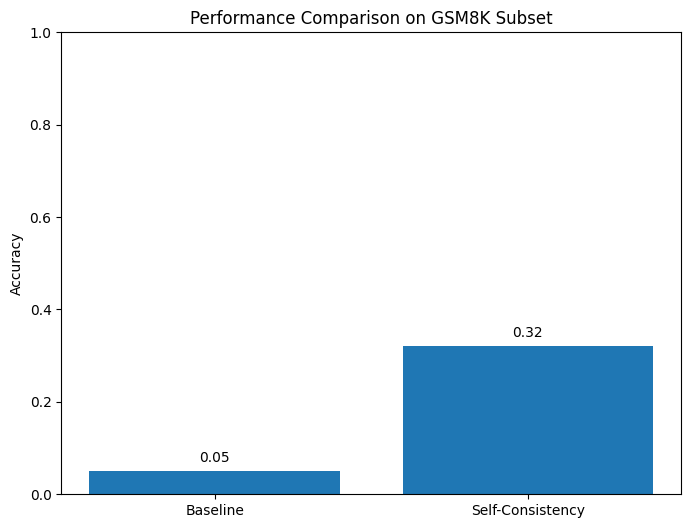

In [7]:
import matplotlib.pyplot as plt

baseline_accuracy = 0.05

labels = ['Baseline', 'Self-Consistency']
accuracies = [baseline_accuracy, final_accuracy]

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies)
plt.title('Performance Comparison on GSM8K Subset')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()